# Wafer defect classification — feature-based MLP

Pipeline:
1. Load WM-811K
2. Helper functions (polar resample, Zernike, angle-radius, connected components)
3. Train/val/test split (balanced per-class budget)
4. Feature extraction (Zernike + angle-radius + CC + CC-radial-extent)
5. MLP training with L1 regularization on first layer + feature pruning mask


## 1. Load data

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PKL_PATH = '/content/drive/MyDrive/LSWMD.pkl.zip'  # adjust if needed
df = pd.read_pickle(PKL_PATH)

def extract_label(x):
    try:
        if isinstance(x, (list, np.ndarray)) and len(x) > 0:
            val = x[0][0] if isinstance(x[0], (list, np.ndarray)) else x[0]
            return str(val) if val else 'unlabeled'
        return 'unlabeled'
    except Exception:
        return 'unlabeled'

df['label'] = df['failureType'].apply(extract_label)

print(f"Shape: {df.shape}")
print("Label counts:")
print(df['label'].value_counts())


Shape: (811457, 7)
Label counts:
label
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## 2. Helper functions

### 2a. Polar resampling

In [4]:
from scipy.ndimage import map_coordinates, binary_erosion


def fit_circle_algebraic(points):
    """Kasa algebraic circle fit. points: (N, 2) of (x, y). Returns (cx, cy, r)."""
    if len(points) < 3:
        return None, None, None
    x, y = points[:, 0], points[:, 1]
    A = np.column_stack([x, y, np.ones_like(x)])
    b = -(x**2 + y**2)
    try:
        sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    except np.linalg.LinAlgError:
        return None, None, None
    D, E, F = sol
    cx, cy = -D/2, -E/2
    r_sq = cx**2 + cy**2 - F
    if r_sq <= 0:
        return None, None, None
    return cx, cy, np.sqrt(r_sq)


def get_wafer_boundary(wm):
    """Fit circle to the outer boundary of non-background pixels."""
    wafer_mask = (wm != 0)
    if not wafer_mask.any():
        return None, None, None
    interior = binary_erosion(wafer_mask)
    boundary = wafer_mask & ~interior
    ys, xs = np.where(boundary)
    if len(xs) < 3:
        return None, None, None
    return fit_circle_algebraic(np.column_stack([xs, ys]))


def polar_resample(wm, n_rho=64, n_theta=180, min_size=25):
    """
    Resample wafer onto polar grid via bilinear interpolation.
    Returns (n_rho, n_theta) array of defect density in [0, 1], or None if
    wafer is too small or boundary fit fails.
    """
    wm = np.array(wm)
    if min(wm.shape) < min_size:
        return None
    cx, cy, r_wafer = get_wafer_boundary(wm)
    if r_wafer is None:
        return None

    defect = (wm == 2).astype(np.float64)
    rho = np.linspace(0, 1, n_rho, endpoint=True)
    theta = np.linspace(0, 2 * np.pi, n_theta, endpoint=False)
    rho_grid, theta_grid = np.meshgrid(rho, theta, indexing='ij')
    x_sample = cx + rho_grid * r_wafer * np.cos(theta_grid)
    y_sample = cy - rho_grid * r_wafer * np.sin(theta_grid)  # image y flipped
    coords = np.stack([y_sample.ravel(), x_sample.ravel()])
    polar = map_coordinates(defect, coords, order=1, mode='constant', cval=0.0)
    return np.clip(polar.reshape(n_rho, n_theta), 0.0, 1.0)


### 2b. Angle-radius features

In [5]:
def angle_radius_features(polar,
                          ang_width_deg=20, ang_step_deg=10,
                          rho_width=0.1, rho_step=0.05):
    """
    Rotation-invariant features from a polar-resampled wafer.
    Returns dict with 'ring_mean' and 'ring_max' arrays (one value per radial bin).
    """
    n_rho, n_theta = polar.shape

    rho_inner = np.arange(0.0, 1.0 - rho_width + 1e-9, rho_step)
    rho_outer = np.minimum(rho_inner + rho_width, 1.0)
    n_rho_bins = len(rho_inner)

    ang_centers = np.arange(0.0, 360.0, ang_step_deg)
    ang_half = ang_width_deg / 2.0

    rho_coords = np.linspace(0, 1, n_rho, endpoint=True)
    theta_coords_deg = np.degrees(np.linspace(0, 2*np.pi, n_theta, endpoint=False))

    raw_grid = np.zeros((len(ang_centers), n_rho_bins), dtype=np.float32)
    for i, c in enumerate(ang_centers):
        d = np.abs((theta_coords_deg - c + 180) % 360 - 180)
        ang_mask = d <= ang_half
        for j in range(n_rho_bins):
            rho_mask = (rho_coords >= rho_inner[j]) & (rho_coords < rho_outer[j])
            if rho_mask.any() and ang_mask.any():
                raw_grid[i, j] = polar[np.ix_(rho_mask, ang_mask)].mean()

    return {
        'ring_mean': raw_grid.mean(axis=0),
        'ring_max': raw_grid.max(axis=0),
        'raw_grid': raw_grid,
        'bin_edges_rho': np.column_stack([rho_inner, rho_outer]),
        'bin_centers_ang': ang_centers,
    }


### 2c. Zernike basis and projection

In [6]:
from math import factorial
from collections import defaultdict


def zernike_radial(n, m, rho):
    m = abs(m)
    if (n - m) % 2 != 0:
        return np.zeros_like(rho)
    R = np.zeros_like(rho)
    for k in range((n - m) // 2 + 1):
        c = ((-1)**k * factorial(n - k)) / (
            factorial(k) * factorial((n + m)//2 - k) * factorial((n - m)//2 - k)
        )
        R += c * rho**(n - 2*k)
    return R


def zernike_nm_pairs(max_order):
    pairs = []
    for n in range(max_order + 1):
        for m in range(-n, n + 1):
            if (n - abs(m)) % 2 == 0:
                pairs.append((n, m))
    return pairs


def build_polar_zernike_basis(n_rho, n_theta, max_order):
    """Build Zernike basis on polar grid plus integration weights."""
    rho_1d = np.linspace(0, 1, n_rho, endpoint=True)
    theta_1d = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    drho = rho_1d[1] - rho_1d[0]
    dtheta = theta_1d[1] - theta_1d[0]
    rho, theta = np.meshgrid(rho_1d, theta_1d, indexing='ij')
    weights = rho * drho * dtheta

    pairs = zernike_nm_pairs(max_order)
    basis = np.zeros((len(pairs), n_rho, n_theta), dtype=np.float64)
    for i, (n, m) in enumerate(pairs):
        R = zernike_radial(n, abs(m), rho)
        if m == 0:
            basis[i] = R
        elif m > 0:
            basis[i] = R * np.cos(m * theta)
        else:
            basis[i] = R * np.sin(abs(m) * theta)
    return basis, weights, pairs


def zernike_features_from_polar(polar, basis, weights, pairs):
    """
    Project polar wafer onto Zernike basis; return rotation-invariant magnitudes.
    For m=0: |c_n0|.  For m!=0: sqrt(c_{n,+m}^2 + c_{n,-m}^2).
    """
    n_arr = np.array([p[0] for p in pairs])
    norm = (n_arr + 1.0) / np.pi
    raw_coeffs = (basis * polar[None, :, :] * weights[None, :, :]).sum(axis=(1, 2)) * norm

    groups = defaultdict(list)
    for i, (n, m) in enumerate(pairs):
        groups[(n, abs(m))].append(raw_coeffs[i])
    mag_labels = sorted(groups.keys())
    magnitudes = np.array([np.sqrt(sum(c**2 for c in groups[k])) for k in mag_labels])
    return magnitudes, mag_labels


### 2d. Connected-component features (native grid)

In [7]:
from scipy.ndimage import label
from skimage.measure import regionprops


def connected_component_features(wm):
    """
    4 CC features on the native binary defect mask (8-connectivity):
      n_comp_norm   : n_components / wafer area
      largest_frac  : largest component size / total defect pixels
      largest_ecc   : eccentricity of largest component (0=circle, 1=line)
      largest_elong : major/minor axis ratio of largest component (>=1)
    """
    wm = np.array(wm)
    defect = (wm == 2)
    wafer_area = int((wm != 0).sum())
    total_defects = int(defect.sum())

    feats = {'n_comp_norm': 0.0, 'largest_frac': 0.0,
             'largest_ecc': 0.0, 'largest_elong': 1.0}
    if total_defects == 0 or wafer_area == 0:
        return feats

    structure = np.ones((3, 3), dtype=np.int32)
    labeled, n_comp = label(defect, structure=structure)
    if n_comp == 0:
        return feats

    feats['n_comp_norm'] = n_comp / wafer_area
    props = regionprops(labeled)
    sizes = np.array([p.area for p in props])
    largest = props[int(np.argmax(sizes))]
    feats['largest_frac'] = sizes.max() / total_defects
    feats['largest_ecc'] = float(largest.eccentricity)
    major = largest.major_axis_length
    minor = largest.minor_axis_length
    if minor > 1e-6:
        feats['largest_elong'] = float(major / minor)
    else:
        feats['largest_elong'] = 100.0 if major > 0 else 1.0
    return feats


def cc_radial_extent_features(wm):
    """
    Radial span of the largest connected component (requires wafer boundary fit):
      cc_rho_max    : max rho across its pixels (does it reach the edge?)
      cc_rho_extent : max(rho) - min(rho) (how far radially does it span?)
    """
    wm = np.array(wm)
    defect = (wm == 2)
    if not defect.any():
        return {'cc_rho_max': 0.0, 'cc_rho_extent': 0.0}
    cx, cy, r = get_wafer_boundary(wm)
    if r is None or r < 1:
        return {'cc_rho_max': 0.0, 'cc_rho_extent': 0.0}
    structure = np.ones((3, 3), dtype=np.int32)
    labeled, n_comp = label(defect, structure=structure)
    if n_comp == 0:
        return {'cc_rho_max': 0.0, 'cc_rho_extent': 0.0}
    sizes = np.bincount(labeled.ravel())[1:]
    largest_label = int(np.argmax(sizes)) + 1
    ys, xs = np.where(labeled == largest_label)
    rhos = np.sqrt((xs - cx)**2 + (ys - cy)**2) / r
    return {'cc_rho_max': float(rhos.max()),
            'cc_rho_extent': float(rhos.max() - rhos.min())}


### 2e. Build Zernike basis (run once)

In [8]:
N_RHO, N_THETA = 64, 180
MAX_ORDER = 8
basis, weights, pairs = build_polar_zernike_basis(N_RHO, N_THETA, MAX_ORDER)
print(f"Zernike basis: {len(pairs)} (n,m) pairs, max order {MAX_ORDER}")


Zernike basis: 45 (n,m) pairs, max order 8


## 3. Train / val / test split

Per-class budget (5000 / 1000 / 1000). Classes with fewer samples get proportional
splits; training set is then oversampled during training to ~500 per class.

In [17]:
CLASS_ORDER = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']
label_to_idx = {c: i for i, c in enumerate(CLASS_ORDER)}

N_TRAIN_PER_CLASS = {
    'none': 50000,
    'Center': 5000, 'Donut': 5000, 'Edge-Loc': 5000, 'Edge-Ring': 5000,
    'Loc': 5000, 'Near-full': 5000, 'Random': 5000, 'Scratch': 5000,
}
N_VAL_PER_CLASS = {
    'none': 1000, 'Center': 1000, 'Donut': 1000, 'Edge-Loc': 1000, 'Edge-Ring': 1000,
    'Loc': 1000, 'Near-full': 1000, 'Random': 1000, 'Scratch': 1000,
}
N_TEST_PER_CLASS = {
    'none': 1000, 'Center': 1000, 'Donut': 1000, 'Edge-Loc': 1000, 'Edge-Ring': 1000,
    'Loc': 1000, 'Near-full': 1000, 'Random': 1000, 'Scratch': 1000,
}
SEED = 42
SEED = 42


def split_per_class(df, label_col='label'):
    train_parts, val_parts, test_parts = [], [], []
    for cls in CLASS_ORDER:
        subset = (df[df[label_col].str.lower() == 'none'] if cls == 'none'
                  else df[df[label_col] == cls])
        n_avail = len(subset)
        subset = subset.sample(frac=1, random_state=SEED).reset_index(drop=True)

        train_target = N_TRAIN_PER_CLASS[cls]
        val_target = N_VAL_PER_CLASS[cls]
        test_target = N_TEST_PER_CLASS[cls]

        n_train = min(train_target, max(n_avail - val_target - test_target, 0))
        n_val = min(val_target, n_avail - n_train)
        n_test = min(test_target, n_avail - n_train - n_val)

        if n_train == 0 and n_avail > 0:
            n_train = max(1, int(0.7 * n_avail))
            n_val = max(1, int(0.15 * n_avail))
            n_test = n_avail - n_train - n_val

        train_parts.append(subset.iloc[:n_train])
        val_parts.append(subset.iloc[n_train:n_train + n_val])
        test_parts.append(subset.iloc[n_train + n_val:n_train + n_val + n_test])
        print(f"  {cls:<10}  avail={n_avail:>6}  "
              f"train={n_train}  val={n_val}  test={n_test}")

    return (pd.concat(train_parts).reset_index(drop=True),
            pd.concat(val_parts).reset_index(drop=True),
            pd.concat(test_parts).reset_index(drop=True))


train_df, val_df, test_df = split_per_class(df)
print(f"\nTotal: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")


  none        avail=147431  train=50000  val=1000  test=1000
  Center      avail=  4294  train=2294  val=1000  test=1000
  Donut       avail=   555  train=388  val=83  test=84
  Edge-Loc    avail=  5189  train=3189  val=1000  test=1000
  Edge-Ring   avail=  9680  train=5000  val=1000  test=1000
  Loc         avail=  3593  train=1593  val=1000  test=1000
  Near-full   avail=   149  train=104  val=22  test=23
  Random      avail=   866  train=606  val=129  test=131
  Scratch     avail=  1193  train=835  val=178  test=180

Total: train=64009, val=5412, test=5418


## 4. Feature extraction

Single function that computes all feature groups at once:
- Zernike magnitudes (|c_nm| at order ≤ 8)
- Angle-radius ring means and maxes
- Connected-component stats (4)
- CC radial extent (2)


In [18]:
from tqdm import tqdm


def extract_features(subset_df, basis, weights, pairs,
                     n_rho=64, n_theta=180, min_size=25):
    """Extract all feature groups. Returns (X, y, feat_names)."""
    X_list, y_list = [], []
    z_names, ar_names = None, None

    for _, row in tqdm(subset_df.iterrows(), total=len(subset_df), leave=False):
        wm = np.array(row['waferMap'])
        polar = polar_resample(wm, n_rho=n_rho, n_theta=n_theta, min_size=min_size)
        if polar is None:
            continue

        mags, mag_labels = zernike_features_from_polar(polar, basis, weights, pairs)
        ar = angle_radius_features(polar)
        ring_vec = np.concatenate([ar['ring_mean'], ar['ring_max']])
        cc = connected_component_features(wm)
        cc_vec = np.array([cc['n_comp_norm'], cc['largest_frac'],
                           cc['largest_ecc'], cc['largest_elong']])
        cc_rad = cc_radial_extent_features(wm)
        cc_rad_vec = np.array([cc_rad['cc_rho_max'], cc_rad['cc_rho_extent']])

        X_list.append(np.concatenate([mags, ring_vec, cc_vec, cc_rad_vec]))
        y_list.append(row['label'])

        if z_names is None:
            z_names = [f"z_{n},{m}" for (n, m) in mag_labels]
            n_rings = len(ar['ring_mean'])
            ar_names = ([f"mean_r{i}" for i in range(n_rings)] +
                        [f"max_r{i}" for i in range(n_rings)])

    feat_names = (z_names + ar_names +
                  ['n_comp_norm', 'largest_frac', 'largest_ecc', 'largest_elong',
                   'cc_rho_max', 'cc_rho_extent'])
    return np.array(X_list, dtype=np.float32), np.array(y_list), feat_names


print("Extracting train...")
X_train, y_train, FEAT_NAMES = extract_features(train_df, basis, weights, pairs)
print("Extracting val...")
X_val, y_val, _ = extract_features(val_df, basis, weights, pairs)
print("Extracting test...")
X_test, y_test, _ = extract_features(test_df, basis, weights, pairs)

print(f"\nShapes: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}")
print(f"Total features: {len(FEAT_NAMES)}")

# Label encoding
y_train_idx = np.array([label_to_idx[l.lower() if l.lower() == 'none' else l] for l in y_train])
y_val_idx = np.array([label_to_idx[l.lower() if l.lower() == 'none' else l] for l in y_val])
y_test_idx = np.array([label_to_idx[l.lower() if l.lower() == 'none' else l] for l in y_test])

# Standardize (fit on train)
feat_mean = X_train.mean(axis=0)
feat_std = X_train.std(axis=0) + 1e-8
X_train_s = (X_train - feat_mean) / feat_std
X_val_s = (X_val - feat_mean) / feat_std
X_test_s = (X_test - feat_mean) / feat_std


Extracting train...


Extracting val...


Extracting test...



Shapes: X_train=(63682, 69), X_val=(5392, 69), X_test=(5378, 69)
Total features: 69


## 5. Train MLP with L1 on first layer

L1 regularization drives unused input weights toward zero. After training,
we identify a pruning mask: the set of features whose first-layer weight
magnitudes account for `KEEP_FRACTION` (e.g. 95%) of the total L1 norm.

`keep_idx` and `keep_mask` are exposed so you can retrain on the reduced
feature set manually.

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# ---- Hyperparameters ----
HIDDEN_1 = 64
HIDDEN_2 = 32
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 512
N_EPOCHS = 150
OVERSAMPLE_TO = 5000
L1_LAMBDA = 1e-3
KEEP_FRACTION = 0.95

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class MLP(nn.Module):
    def __init__(self, n_in, n_classes, hidden_1, hidden_2, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_2, n_classes),
        )

    def forward(self, x):
        return self.net(x)


# ---- Oversampling sampler ----
class_counts = np.bincount(y_train_idx, minlength=len(CLASS_ORDER))
print(f"Train class counts: {dict(zip(CLASS_ORDER, class_counts))}")
sample_weights = 1.0 / class_counts[y_train_idx]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=OVERSAMPLE_TO * len(CLASS_ORDER),
    replacement=True,
)

# ---- Data loaders ----
X_train_t = torch.from_numpy(X_train_s)
y_train_t = torch.from_numpy(y_train_idx).long()
X_val_t = torch.from_numpy(X_val_s)
y_val_t = torch.from_numpy(y_val_idx).long()
X_test_t = torch.from_numpy(X_test_s)
y_test_t = torch.from_numpy(y_test_idx).long()

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t),
                        batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=BATCH_SIZE, shuffle=False)

# ---- Model, optimizer, loss ----
model = MLP(X_train.shape[1], len(CLASS_ORDER), HIDDEN_1, HIDDEN_2, DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
first_linear = model.net[0]

n_params = sum(p.numel() for p in model.parameters())
print(f"Input features: {X_train.shape[1]} | Model params: {n_params} | "
      f"L1 lambda: {L1_LAMBDA} | keep frac: {KEEP_FRACTION}")


# ---- Eval helper ----
def evaluate(model, loader):
    model.eval()
    total_loss, preds, trues = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * xb.size(0)
            preds.append(logits.argmax(dim=1).cpu().numpy())
            trues.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    macro_f1 = f1_score(trues, preds, average='macro', zero_division=0)
    return total_loss / len(loader.dataset), macro_f1, preds, trues


# ---- Training loop ----
history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': []}

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_ce, n_seen = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        ce_loss = criterion(logits, yb)
        l1_penalty = first_linear.weight.abs().sum()
        loss = ce_loss + L1_LAMBDA * l1_penalty
        loss.backward()
        optimizer.step()
        epoch_ce += ce_loss.item() * xb.size(0)
        n_seen += xb.size(0)
    train_loss = epoch_ce / n_seen

    val_loss, val_f1, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_macro_f1'].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | ce={train_loss:.4f} "
              f"val_ce={val_loss:.4f} val_f1={val_f1:.4f}")


# ---- Test evaluation ----
test_loss, test_f1, test_preds, test_trues = evaluate(model, test_loader)
print(f"\nTEST: loss={test_loss:.4f} macro_f1={test_f1:.4f}")
print("\nPer-class report:")
print(classification_report(test_trues, test_preds,
                            target_names=CLASS_ORDER, zero_division=0))


# ---- Pruning mask from first-layer L1 usage ----
with torch.no_grad():
    feat_usage = first_linear.weight.abs().sum(dim=0).cpu().numpy()

sorted_idx = np.argsort(feat_usage)[::-1]
sorted_usage = feat_usage[sorted_idx]
cum_frac = np.cumsum(sorted_usage) / sorted_usage.sum()
n_keep = int(np.searchsorted(cum_frac, KEEP_FRACTION) + 1)
keep_idx = np.sort(sorted_idx[:n_keep])
keep_mask = np.zeros(X_train.shape[1], dtype=bool)
keep_mask[keep_idx] = True

print(f"\nPruning: kept {n_keep} / {X_train.shape[1]} features "
      f"({100*n_keep/X_train.shape[1]:.1f}%) "
      f"accounting for {100*cum_frac[n_keep-1]:.1f}% of |W_1|")
print("Kept features:")
for i in keep_idx:
    print(f"  [{i:>3}] {FEAT_NAMES[i]:<20}  usage={feat_usage[i]:.3f}")


Using device: cuda
Train class counts: {'none': np.int64(49732), 'Center': np.int64(2292), 'Donut': np.int64(388), 'Edge-Loc': np.int64(3145), 'Edge-Ring': np.int64(4998), 'Loc': np.int64(1588), 'Near-full': np.int64(104), 'Random': np.int64(605), 'Scratch': np.int64(830)}
Input features: 69 | Model params: 6857 | L1 lambda: 0.001 | keep frac: 0.95
Epoch   1 | ce=1.4457 val_ce=0.9191 val_f1=0.6075
Epoch   5 | ce=0.5021 val_ce=0.4512 val_f1=0.7984
Epoch  10 | ce=0.4186 val_ce=0.4060 val_f1=0.7994
Epoch  15 | ce=0.3787 val_ce=0.3853 val_f1=0.8226
Epoch  20 | ce=0.3670 val_ce=0.3667 val_f1=0.8293
Epoch  25 | ce=0.3385 val_ce=0.3654 val_f1=0.8257
Epoch  30 | ce=0.3302 val_ce=0.3540 val_f1=0.8332
Epoch  35 | ce=0.3208 val_ce=0.3547 val_f1=0.8321
Epoch  40 | ce=0.3135 val_ce=0.3421 val_f1=0.8457
Epoch  45 | ce=0.3082 val_ce=0.3538 val_f1=0.8465
Epoch  50 | ce=0.2997 val_ce=0.3474 val_f1=0.8417
Epoch  55 | ce=0.2890 val_ce=0.3364 val_f1=0.8504
Epoch  60 | ce=0.2902 val_ce=0.3487 val_f1=0.8423

### Re-train using L1-survived features

In [22]:
# ---- Retrain on reduced features only ----
# Uses: keep_idx, y_train_idx, y_val_idx, y_test_idx, sampler, CLASS_ORDER,
#       FEAT_NAMES, MLP, evaluate, HIDDEN_1, HIDDEN_2, DROPOUT, LR,
#       WEIGHT_DECAY, BATCH_SIZE, N_EPOCHS, device, criterion

X_train_r = X_train_s[:, keep_idx]
X_val_r = X_val_s[:, keep_idx]
X_test_r = X_test_s[:, keep_idx]
FEAT_NAMES_r = [FEAT_NAMES[i] for i in keep_idx]

train_loader_r = DataLoader(
    TensorDataset(torch.from_numpy(X_train_r), torch.from_numpy(y_train_idx).long()),
    batch_size=BATCH_SIZE, sampler=sampler,
)
val_loader_r = DataLoader(
    TensorDataset(torch.from_numpy(X_val_r), torch.from_numpy(y_val_idx).long()),
    batch_size=BATCH_SIZE, shuffle=False,
)
test_loader_r = DataLoader(
    TensorDataset(torch.from_numpy(X_test_r), torch.from_numpy(y_test_idx).long()),
    batch_size=BATCH_SIZE, shuffle=False,
)

model_r = MLP(X_train_r.shape[1], len(CLASS_ORDER), HIDDEN_1, HIDDEN_2, DROPOUT).to(device)
optimizer_r = torch.optim.Adam(model_r.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_params_r = sum(p.numel() for p in model_r.parameters())
print(f"Reduced: {X_train_r.shape[1]} features | {n_params_r} params")

history_r = {'train_loss': [], 'val_loss': [], 'val_macro_f1': []}
for epoch in range(1, N_EPOCHS + 1):
    model_r.train()
    epoch_ce, n_seen = 0.0, 0
    for xb, yb in train_loader_r:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_r.zero_grad()
        loss = criterion(model_r(xb), yb)  # no L1
        loss.backward()
        optimizer_r.step()
        epoch_ce += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    train_loss = epoch_ce / n_seen
    val_loss, val_f1, _, _ = evaluate(model_r, val_loader_r)
    history_r['train_loss'].append(train_loss)
    history_r['val_loss'].append(val_loss)
    history_r['val_macro_f1'].append(val_f1)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | ce={train_loss:.4f} "
              f"val_ce={val_loss:.4f} val_f1={val_f1:.4f}")

test_loss, test_f1, test_preds_r, test_trues_r = evaluate(model_r, test_loader_r)
print(f"\nREDUCED TEST: macro_f1={test_f1:.4f}")
print(classification_report(test_trues_r, test_preds_r,
                            target_names=CLASS_ORDER, zero_division=0))

Reduced: 61 features | 6345 params
Epoch   1 | ce=1.5111 val_ce=0.9865 val_f1=0.5519
Epoch   5 | ce=0.4984 val_ce=0.4564 val_f1=0.7938
Epoch  10 | ce=0.4039 val_ce=0.3979 val_f1=0.8139
Epoch  15 | ce=0.3609 val_ce=0.3760 val_f1=0.8272
Epoch  20 | ce=0.3376 val_ce=0.3642 val_f1=0.8306
Epoch  25 | ce=0.3176 val_ce=0.3576 val_f1=0.8337
Epoch  30 | ce=0.3076 val_ce=0.3479 val_f1=0.8417
Epoch  35 | ce=0.2905 val_ce=0.3438 val_f1=0.8393
Epoch  40 | ce=0.2846 val_ce=0.3338 val_f1=0.8536
Epoch  45 | ce=0.2800 val_ce=0.3453 val_f1=0.8404
Epoch  50 | ce=0.2722 val_ce=0.3351 val_f1=0.8447
Epoch  55 | ce=0.2645 val_ce=0.3339 val_f1=0.8482
Epoch  60 | ce=0.2626 val_ce=0.3275 val_f1=0.8533
Epoch  65 | ce=0.2675 val_ce=0.3318 val_f1=0.8491
Epoch  70 | ce=0.2555 val_ce=0.3361 val_f1=0.8471
Epoch  75 | ce=0.2500 val_ce=0.3302 val_f1=0.8501
Epoch  80 | ce=0.2478 val_ce=0.3298 val_f1=0.8486
Epoch  85 | ce=0.2393 val_ce=0.3261 val_f1=0.8599
Epoch  90 | ce=0.2408 val_ce=0.3266 val_f1=0.8516
Epoch  95 | ce=

## 6. Training curves and confusion matrix

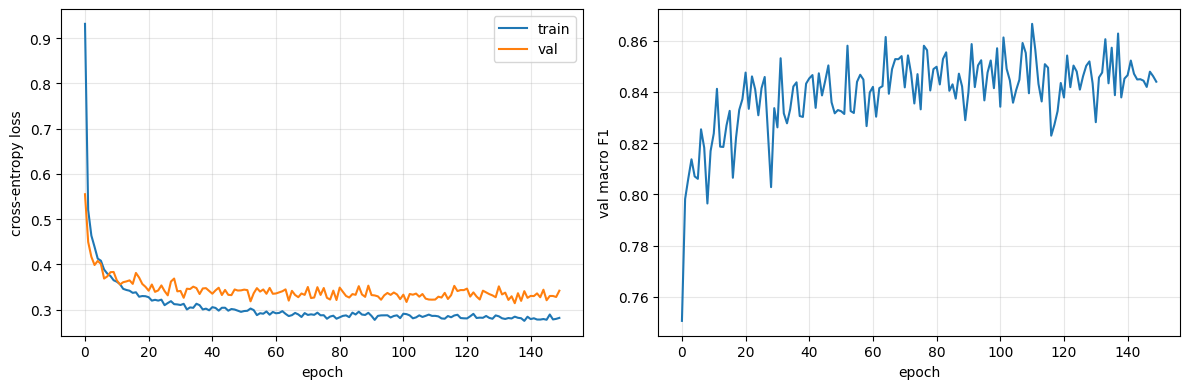

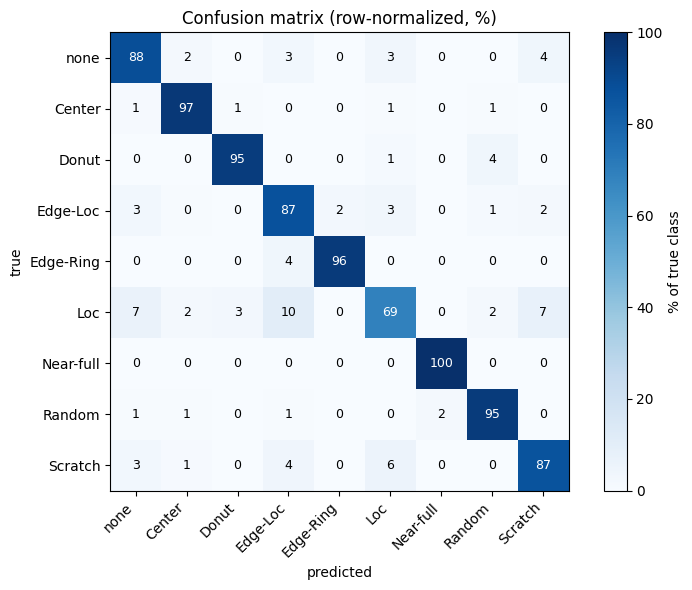

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy loss'); axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(history['val_macro_f1'])
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro F1')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

cm = confusion_matrix(test_trues, test_preds)
cm_pct = 100.0 * cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
ax.set_xticks(range(len(CLASS_ORDER))); ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=45, ha='right')
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
for i in range(len(CLASS_ORDER)):
    for j in range(len(CLASS_ORDER)):
        val = cm_pct[i, j]
        ax.text(j, i, f"{val:.0f}", ha='center', va='center',
                color='white' if val > 50 else 'black', fontsize=9)
plt.colorbar(im, label='% of true class')
plt.title('Confusion matrix (row-normalized, %)')
plt.tight_layout(); plt.show()
